# 03 - Released Key

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import pygame

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250507_132315.parquet")

## Rutinas

In [34]:

# cuando key pasa de un valor > 0 a 0 → release
df["key_prev"] = df["key"].shift(1)

# Detectar presiones y liberaciones directamente
pressed_times = df[(df["key_prev"] == 0) & (df["key"] > 0)]["timestamp"].reset_index(drop=True)
df_released = df[(df["key_prev"] > 0) & (df["key"] == 0)][["timestamp", "key_prev"]].reset_index(drop=True)

# Lo he puesto opcional calcular cuánto mantienen presionada la tecla
df_released["press_time"] = pressed_times
df_released["duracion_ms"] = df_released["timestamp"] - df_released["press_time"]


df_released["key_prev"] = df_released["key_prev"].astype(int)
df_released["key_name"] = df_released["key_prev"].apply(pygame.key.name)

print(df_released)

       timestamp  key_prev     press_time  duracion_ms key_name
0  1746616978421        32  1746616978371           50    space
1  1746616981295       115  1746616981213           82        s
2  1746616984671       119  1746616984590           81        w
3  1746616987692       107  1746616987625           67        k
4  1746616990466       107  1746616990400           66        k
5  1746616994600       119  1746616994484          116        w


## Duración pulsación por tecla

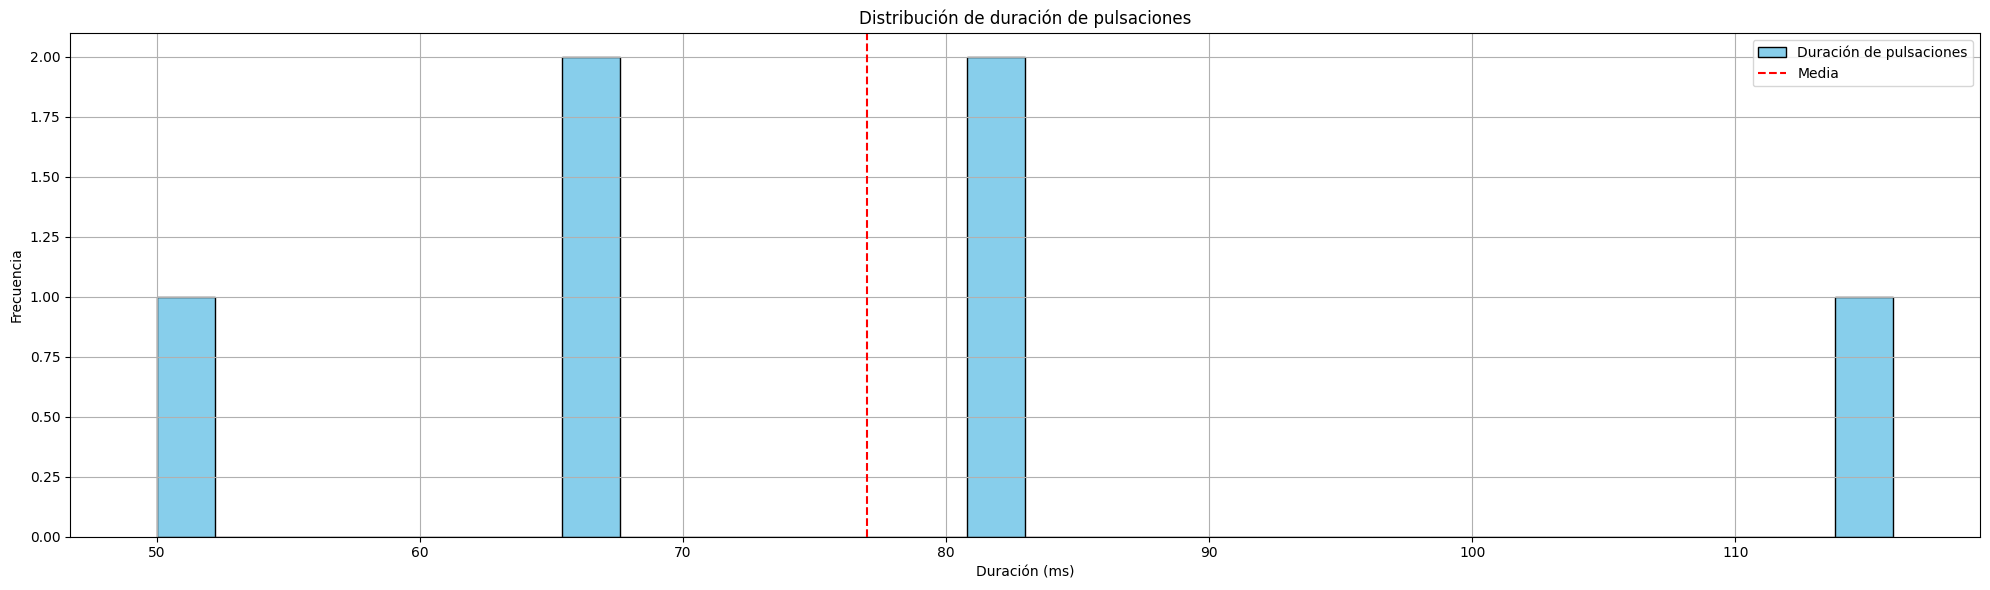

In [35]:
plt.hist(df_released["duracion_ms"], bins=30, color="skyblue", edgecolor="black", label="Duración de pulsaciones")
plt.axvline(df_released["duracion_ms"].mean(), color="r", linestyle="--", label="Media")
plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de pulsaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Si la mayoría de las pulsaciones duran menos de 200 ms → el usuario teclea rápido.
# Si hay pulsaciones largas o picos raros → puede indicar errores, pausas, o que mantuvo teclas apretadas.

Mismo codigo pero enriquecido con percentiles 

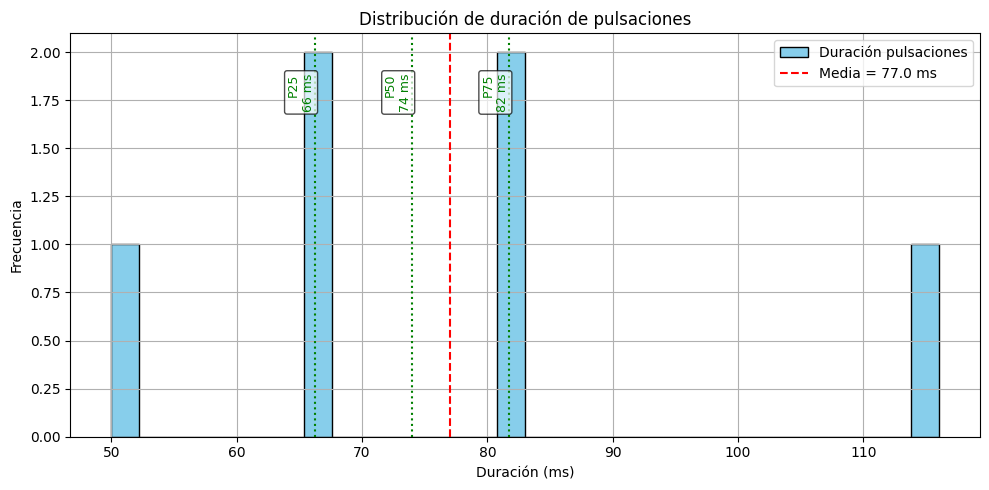

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Serie limpia de duraciones
duraciones = df_released.loc[df_released["duracion_ms"] > 0, "duracion_ms"]

# ===== 1) Histograma con media + percentiles =====
plt.figure(figsize=(10,5))
plt.hist(duraciones, bins=30, color="skyblue", edgecolor="black", label="Duración pulsaciones")
plt.axvline(duraciones.mean(), color="r", linestyle="--", label=f"Media = {duraciones.mean():.1f} ms")

p25, p50, p75 = np.percentile(duraciones, [25,50,75])
for val, lab in zip([p25,p50,p75], ["P25","P50","P75"]):
    plt.axvline(val, color="g", linestyle=":")
    plt.text(val, plt.ylim()[1]*0.9, f"{lab}\n{val:.0f} ms",
             rotation=90, va="top", ha="right", color="g", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))


plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de pulsaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Cómo se interpreta:

- Si la mayoría de pulsaciones están <200 ms → el tecleo es rápido y fluido.

- Si hay una cola larga hacia la derecha (>400–500 ms) → indica pulsaciones mantenidas o irregulares (posibles pausas, errores, vacilaciones).

- Si la distribución es muy ancha o multimodal, refleja inconsistencia en el control motor.

Relevancia clínica (SCA2): En sujetos con ataxia se espera:

- Media más alta (tiempos más largos).
- Mayor dispersión (inestabilidad).
- Outliers frecuentes (pulsaciones mantenidas anómalas).

Percentiles: 
- P25 marca el límite inferior de las pulsaciones rápidas.
- P50 (la mediana) es la “pulsación típica”.
- P75 marca el límite superior de las pulsaciones largas.

Detectar dispersión:

La distancia entre P25 y P75 se llama rango intercuartílico (IQR).

- Si el IQR es estrecho → el tecleo es estable.
- Si es ancho → mucha irregularidad (inestabilidad motora en SCA2).

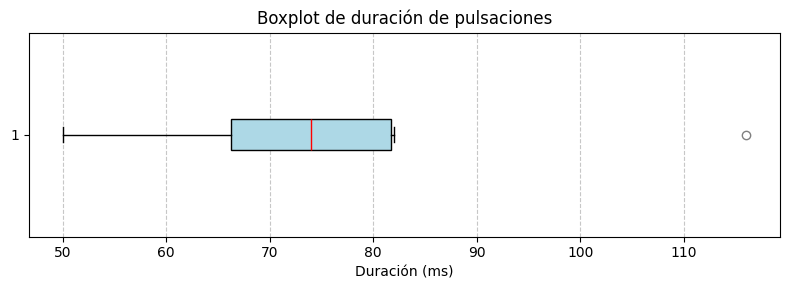

In [37]:

# ===== 2) Boxplot =====
plt.figure(figsize=(8,3))
plt.boxplot(duraciones, vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color="black", alpha=0.5))
plt.xlabel("Duración (ms)")
plt.title("Boxplot de duración de pulsaciones")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




BOXPLOT 
Qué es: Una línea horizontal con la mediana (rojo), la caja del rango intercuartílico (P25–P75) y puntos aislados (outliers).

Cómo se interpreta:

- Caja estrecha → tecleo consistente.
- Caja ancha → mucha variabilidad.
- Muchos outliers largos → pulsaciones extremadamente largas (ej. bloqueos motores, dudas).

Relevancia clínica:
En ataxia se espera un boxplot “hinchado” (mayor rango intercuartílico) y con outliers abundantes, porque la persona no mantiene un patrón estable de presión de teclas.

Resumir sin dejarse engañar por outliers:

- La media se distorsiona si hay pulsaciones muy largas.
- La mediana (P50) es más robusta → refleja la pulsación “típica”.

Comparar condiciones o grupos:

Puedes ver si en un grupo clínico (ej. pacientes) los percentiles se desplazan hacia valores más altos (pulsaciones más lentas) o se abren más (más variabilidad).

Visión clínica intuitiva:

En un boxplot, P25–P75 son los bordes de la “caja”. Se interpreta fácilmente: la mayoría de pulsaciones están ahí, y lo que queda fuera son posibles anomalías.

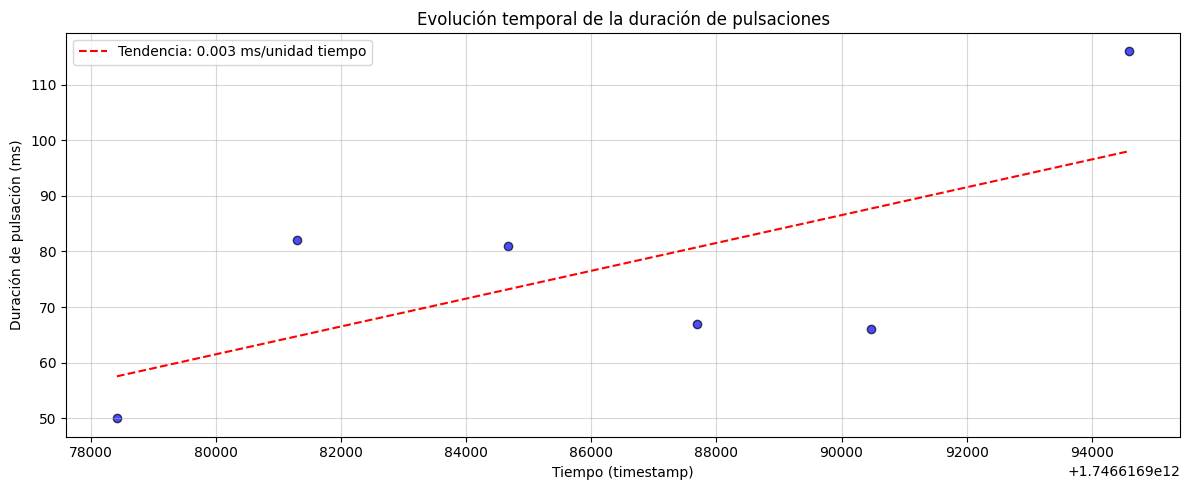

In [38]:
# ===== 3) Timeline (auto-detecta la columna de tiempo) =====
# Busca una columna de tiempo válida en df_released
time_col = next((c for c in ["release_ts", "timestamp", "time", "t"] if c in df_released.columns), None)
if time_col is None:
    raise KeyError("No se encontró columna de tiempo en df_released. Añade 'timestamp' o 'release_ts'.")

# Filtra filas con duración válida y tiempo no nulo
mask = (df_released["duracion_ms"] > 0) & df_released[time_col].notna()
x = df_released.loc[mask, time_col]
y = df_released.loc[mask, "duracion_ms"]

plt.figure(figsize=(12,5))
plt.scatter(x, y, c="blue", alpha=0.7, edgecolors="black")
plt.xlabel(f"Tiempo ({time_col})")
plt.ylabel("Duración de pulsación (ms)")
plt.title("Evolución temporal de la duración de pulsaciones")
plt.grid(True, alpha=0.5)

# Línea de tendencia (solo si hay suficientes puntos)
if len(y) >= 3:
    # Convierte a float por si son timestamps tipo int64
    x_float = x.astype(float)
    coeffs = np.polyfit(x_float, y.astype(float), 1)
    trend = np.polyval(coeffs, x_float)
    plt.plot(x, trend, color="red", linestyle="--",
             label=f"Tendencia: {coeffs[0]:.3f} ms/unidad tiempo")
    plt.legend()

plt.tight_layout()
plt.show()

TEMPORALIDAD
Qué es:
Un gráfico de dispersión de la duración de cada pulsación en función del tiempo. A veces con una línea de tendencia roja.

Cómo se interpreta:

- Si los puntos están estables en el tiempo → el participante mantiene ritmo constante.
- Si la tendencia roja sube → fatigabilidad (cada vez cuesta más, las pulsaciones se alargan).
- Si hay grandes saltos o variabilidad creciente → refleja pérdida de control motor con el paso del tiempo.

Relevancia clínica:
La tendencia creciente es muy típica de patologías progresivas como SCA2: al principio pueden mantener cierta coordinación, pero se deteriora con la repetición.

## Duración pulsaciones según lado del teclado

La idea es observar si hay variabilidad según cada lado del teclado con el objetivo de poder valorar si un hemisferio presenta más afección que otro. Brazo izq controlado por hemisferio derecho, Brazo derecho contorlado por hemisferio izq.

           mean        std  count        cv
lado                                       
Derecha    66.5   0.707107      2  0.010633
Izquierda  93.0  19.924859      3  0.214246
Otro       50.0        NaN      1       NaN


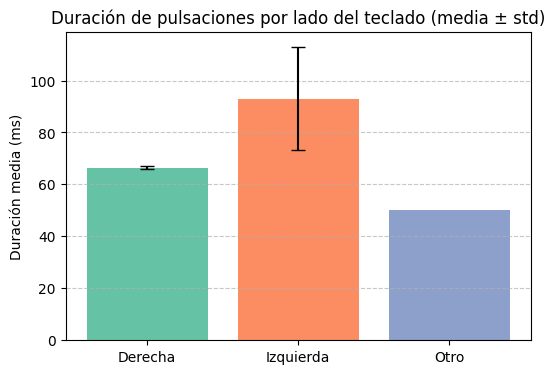

In [39]:
# Definir teclas de cada lado (aprox. teclado QWERTY español)
left_keys  = set("12345qwertasdfgzxcvb")
right_keys = set("67890yuiopñhjklm,.-")

# Clasificar cada tecla
def lado_tecla(tecla):
    if tecla in left_keys: return "Izquierda"
    if tecla in right_keys: return "Derecha"
    return "Otro"

df_released["lado"] = df_released["key_name"].apply(lambda k: lado_tecla(k.lower()))

# Métricas por lado
resumen_lados = df_released.groupby("lado")["duracion_ms"].agg(["mean","std","count"])
resumen_lados["cv"] = resumen_lados["std"] / resumen_lados["mean"]
print(resumen_lados)

import seaborn as sns

resumen = df_released.groupby("lado")["duracion_ms"].agg(["mean","std","count"]).reset_index()

plt.figure(figsize=(6,4))
plt.bar(resumen["lado"], resumen["mean"], yerr=resumen["std"], capsize=5, color=["#66c2a5","#fc8d62","#8da0cb"])
plt.ylabel("Duración media (ms)")
plt.title("Duración de pulsaciones por lado del teclado (media ± std)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Cada barra = media de un lado, con una línea de error que marca la variabilidad.
En un barplot con error bars:

- La barra es la media.
- Las líneas que salen arriba y abajo (error bars) indican ±1 std.
- Si son cortas → las pulsaciones son consistentes.
- Si son largas → hay mucha irregularidad.

En ataxias como SCA2 no solo importa que sean más lentos (media mayor), sino que también son menos consistentes (mayor variabilidad). Eso es un biomarcador muy potente: distingue entre alguien que simplemente teclea más despacio (pero regular) y alguien con descoordinación motora (tiempos muy irregulares).

In [40]:
# Añadir el color a df_released (suponiendo que index o trial_id coincide)
df_released["color"] = df_resultados.loc[df_released.index, "color"]

# Métricas por lado y color
resumen_color_lado = df_released.groupby(["color","lado"])["duracion_ms"].agg(["mean","std","count"])
print(resumen_color_lado)


NameError: name 'df_resultados' is not defined

## Línea temporal de pulsaciones

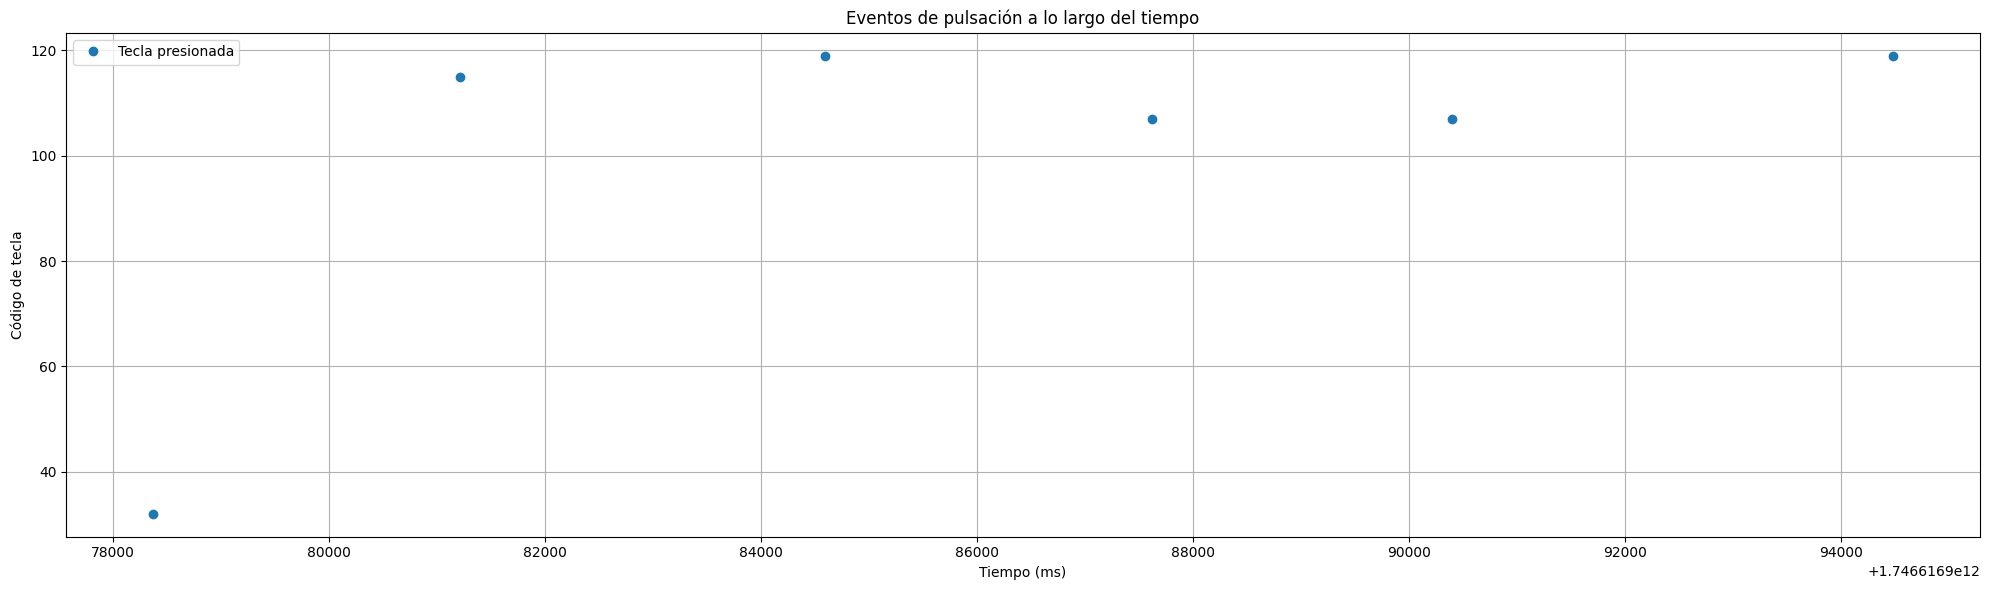

In [ ]:
plt.plot(df_released["press_time"], df_released["key_prev"], 'o', label="Tecla presionada")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Código de tecla")
plt.title("Eventos de pulsación a lo largo del tiempo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Duración media de pulsaciones por tecla

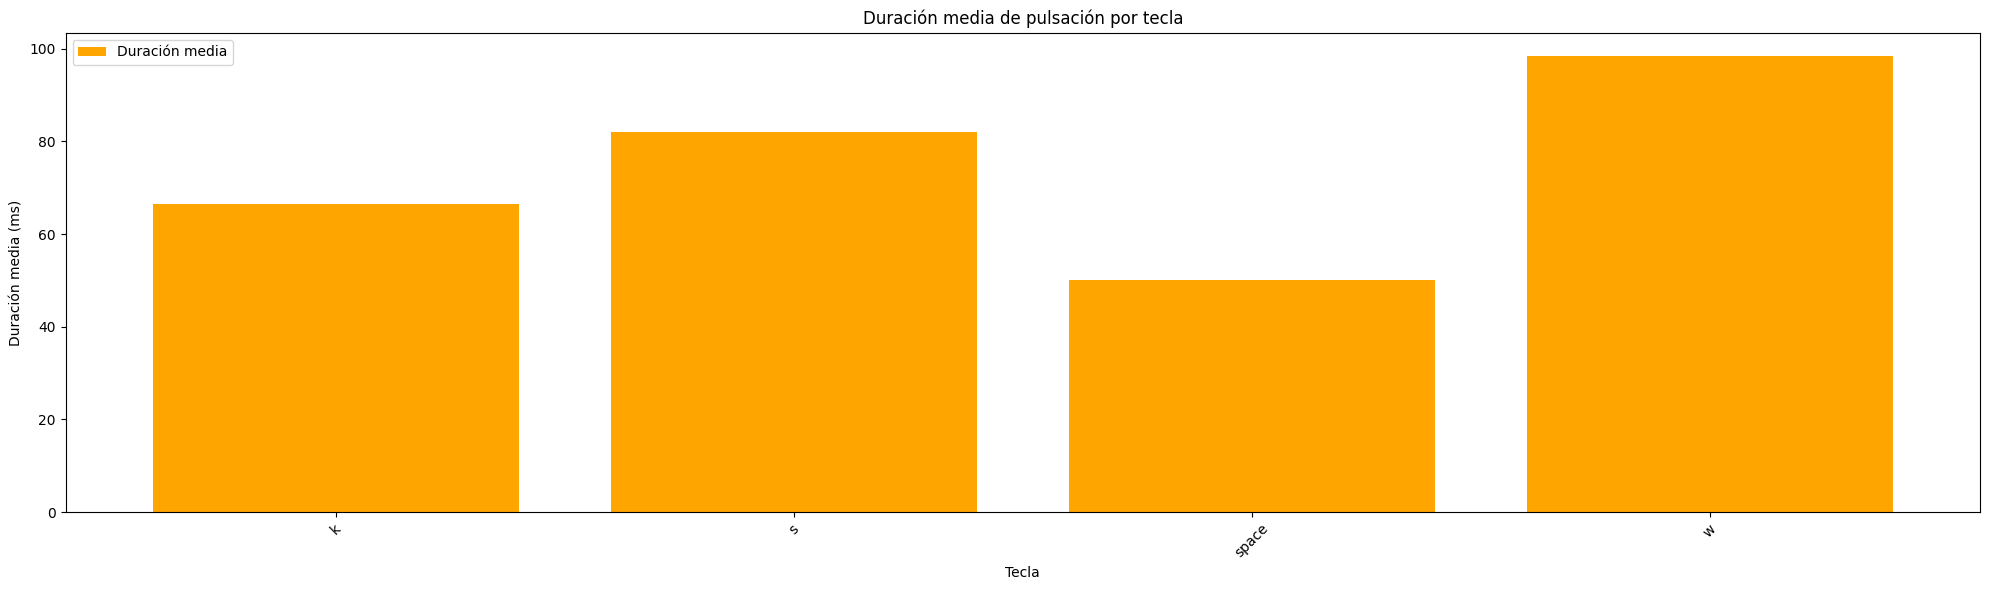

In [ ]:
duracion_media = df_released.groupby("key_name")["duracion_ms"].mean()


plt.bar(duracion_media.index, duracion_media.values, color="orange", label="Duración media")
plt.xlabel("Tecla")
plt.ylabel("Duración media (ms)")
plt.title("Duración media de pulsación por tecla")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Frecuencia de teclas presionadas

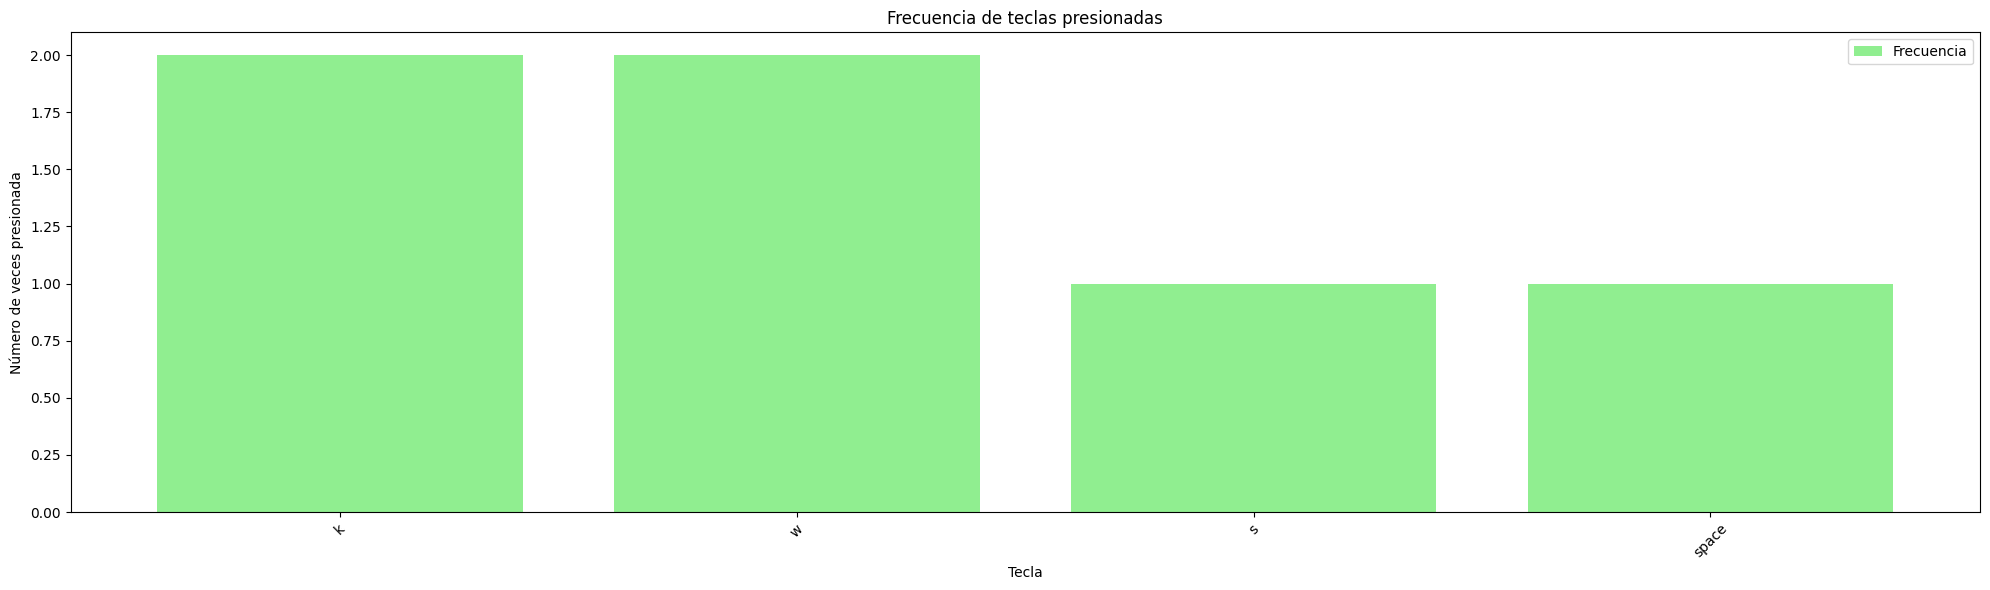

In [ ]:
key_counts = df_released["key_name"].value_counts()


plt.bar(key_counts.index, key_counts.values, color="lightgreen", label="Frecuencia")
plt.xlabel("Tecla")
plt.ylabel("Número de veces presionada")
plt.title("Frecuencia de teclas presionadas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
